# EDA - Sentiment analysis

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# sklearn for TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Word cloud
from wordcloud import WordCloud


### Load and Clean the data

In [80]:
DATA_PATH = '../data/newsData/raw_analyst_ratings.csv'

df = pd.read_csv(DATA_PATH, index_col=0)#remove the first column which is just an index

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (1407328, 5)
Columns: ['headline', 'url', 'publisher', 'date', 'stock']


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [81]:
#clean up the date by removing time zones and making all midnight only (zero out HH:MM:SS)
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)  # parse it
df['date'] = df['date'].dt.tz_localize(None)   # strip the -04:00 timezone
df['date'] = df['date'].dt.normalize()          # zero out HH:MM:SS → midnight only

print('cleaned date:', df['date'].iloc[0])

print(f'Number of missing dates: {df["date"].isna().sum()}')

cleaned date: 2020-06-05 00:00:00
Number of missing dates: 0


In [82]:
df.isna().sum()#check for missing values in all columns
# Drop rows missing critical fields
df = df.dropna(subset=['headline', 'stock', 'date'])
df = df.drop_duplicates()
print(f'Clean shape: {df.shape}')
df.head(3)

Clean shape: (1407326, 5)


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26,A


## Descriptove Statistics

In [83]:
print('=== Dataset Overview ===')
print(f'Total articles   : {len(df):,}')
print(f'Unique stocks    : {df["stock"].nunique():,}')
print(f'Unique publishers: {df["publisher"].nunique():,}')
print(f'Date range       : {df["date"].min().date()} → {df["date"].max().date()}')

=== Dataset Overview ===
Total articles   : 1,407,326
Unique stocks    : 6,204
Unique publishers: 1,034
Date range       : 2009-02-14 → 2020-06-11


### headline character length and distribution

In [84]:
# Compute headline character counts
df['headline_char_count'] = df['headline'].str.len()

# print summary statistics for headline lengths
print('\n=== Headline Length Statistics ===')
print(df['headline_char_count'].describe().round(1))


=== Headline Length Statistics ===
count    1407326.0
mean          73.1
std           40.7
min            3.0
25%           47.0
50%           64.0
75%           87.0
max          512.0
Name: headline_char_count, dtype: float64


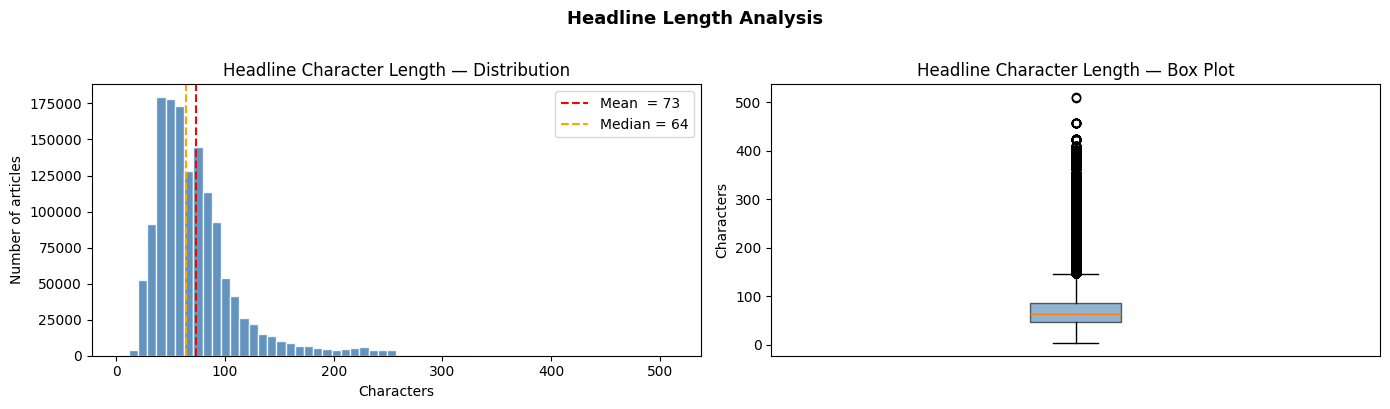


Top 1% threshold: 235 chars
Extreme headlines (>235 chars): 13591


In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['headline_char_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['headline_char_count'].mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean  = {df["headline_char_count"].mean():.0f}')
axes[0].axvline(df['headline_char_count'].median(), color='orange', linestyle='--', lw=1.5, label=f'Median = {df["headline_char_count"].median():.0f}')
axes[0].set_title('Headline Character Length — Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Number of articles')
axes[0].legend()


# Box plot — easy way to spot outliers
axes[1].boxplot(df['headline_char_count'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Headline Character Length — Box Plot')
axes[1].set_ylabel('Characters')
axes[1].set_xticks([])

plt.suptitle('Headline Length Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_headline_length.png', dpi=150, bbox_inches='tight')
plt.show()


# Flag extreme outliers
q99 = df['headline_char_count'].quantile(0.99)
print(f'\nTop 1% threshold: {q99:.0f} chars')
print(f'Extreme headlines (>{q99:.0f} chars): {(df["headline_char_count"] > q99).sum()}')

### Article per stock 


=== Top 10 Stocks by Article Count ===
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64


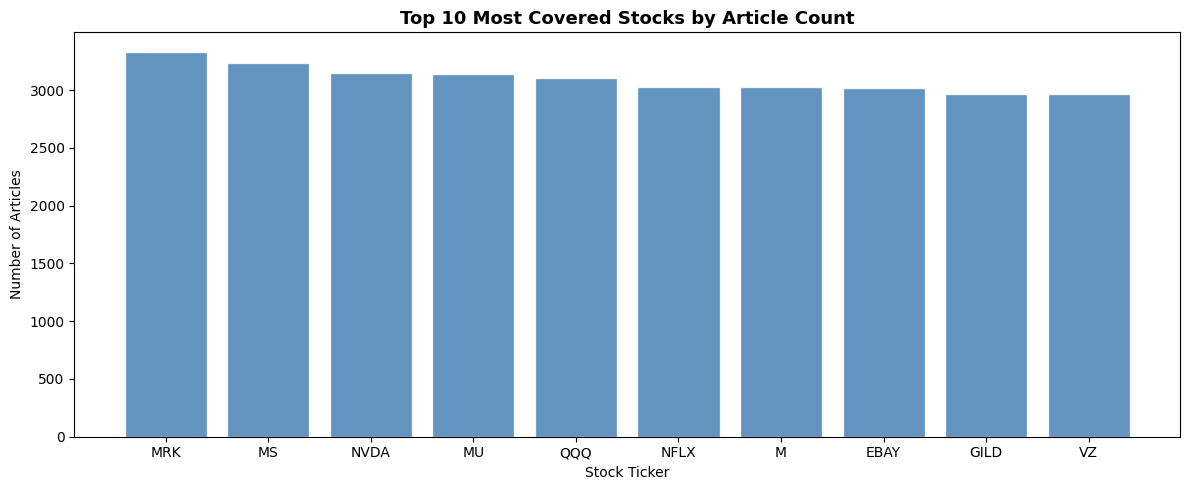

       Article Count
stock               
MRK             3333
MS              3238
NVDA            3146
MU              3142
QQQ             3106
NFLX            3028
M               3025
EBAY            3018
GILD            2968
VZ              2966


In [86]:
# Count articles per stock ticker, show top 10
articles_per_stock = df['stock'].value_counts().head(10)
print('\n=== Top 10 Stocks by Article Count ===')
print(articles_per_stock)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(articles_per_stock.index, articles_per_stock.values,
              color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Top 10 Most Covered Stocks by Article Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Stock Ticker')
ax.set_ylabel('Number of Articles')
plt.tight_layout()
plt.show()

print(articles_per_stock.to_frame('Article Count').head(10))

# Publshers Analysis

Total unique publishers: 1,034

Top 15 publishers:
                   Articles
publisher                  
Paul Quintaro        228373
Lisa Levin           186978
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57253
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050


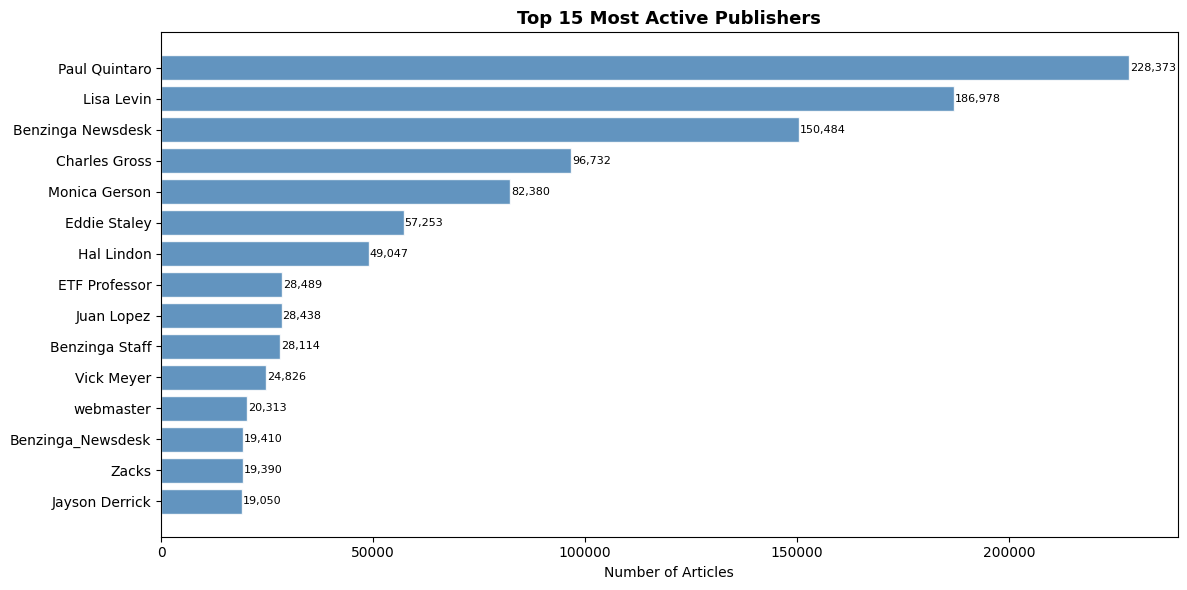

In [87]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()

print(f'Total unique publishers: {publisher_counts.shape[0]:,}')
print('\nTop 15 publishers:')
print(publisher_counts.head(15).to_frame('Articles'))

top15 = publisher_counts.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color='steelblue', edgecolor='white', alpha=0.85)

for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,}', va='center', fontsize=8)

ax.set_title('Top 15 Most Active Publishers', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Articles')
plt.tight_layout()
plt.show()

### Time Series Analysis of News Volume

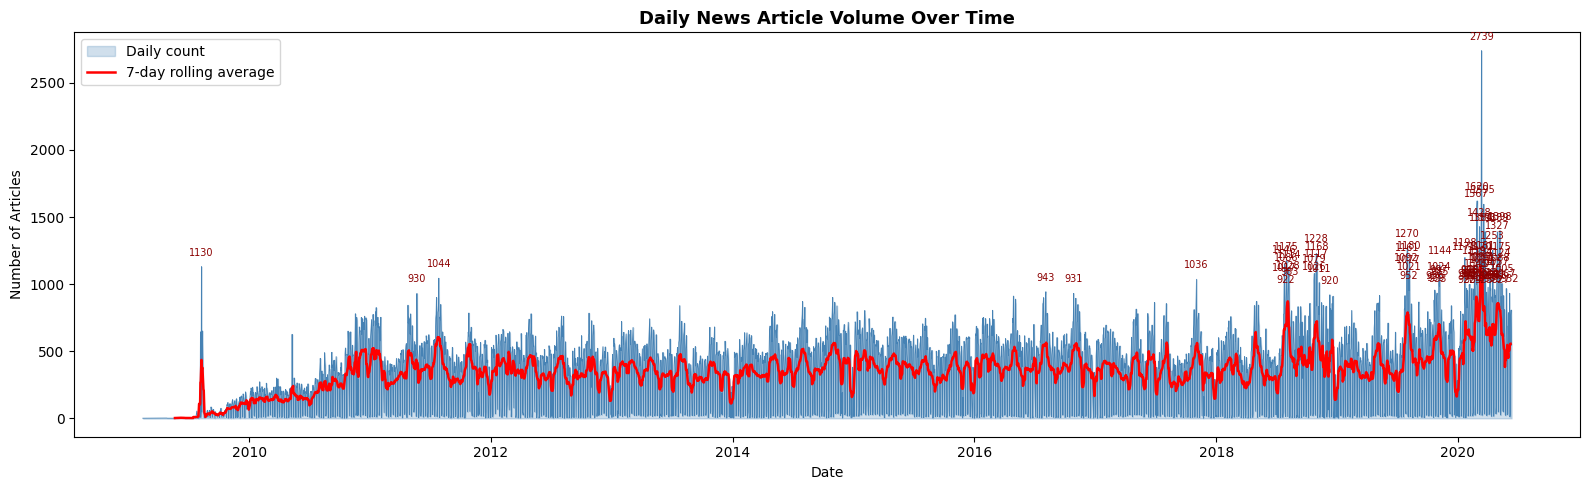

Average daily articles : 356
Max daily articles     : 2739 on 2020-03-12
Spike threshold (μ+2σ) : 919
Spike days count       : 85


In [88]:
# Group by date and count rows
# .dt.date gives plain Python date objects which plot cleanly on the x-axis
daily_volume = df.groupby(df['date'].dt.date).size().rename('article_count')
daily_volume.index = pd.to_datetime(daily_volume.index)  # convert back to datetime for rolling

# 7-day rolling average to smooth the noise
rolling_7d = daily_volume.rolling(window=7, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(daily_volume.index, daily_volume.values,
                alpha=0.25, color='steelblue', label='Daily count')
ax.plot(daily_volume.index, daily_volume.values, color='steelblue', lw=0.6)
ax.plot(rolling_7d.index, rolling_7d.values, color='red', lw=1.8,
        label='7-day rolling average')

# Annotate notable spikes automatically
spike_threshold = daily_volume.mean() + 2 * daily_volume.std()
spikes = daily_volume[daily_volume > spike_threshold]
for dt, val in spikes.items():
    ax.annotate(f'{val}', xy=(dt, val), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=7, color='darkred')

ax.set_title('Daily News Article Volume Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Average daily articles : {daily_volume.mean():.0f}')
print(f'Max daily articles     : {daily_volume.max()} on {daily_volume.idxmax().date()}')
print(f'Spike threshold (μ+2σ) : {spike_threshold:.0f}')
print(f'Spike days count       : {len(spikes)}')

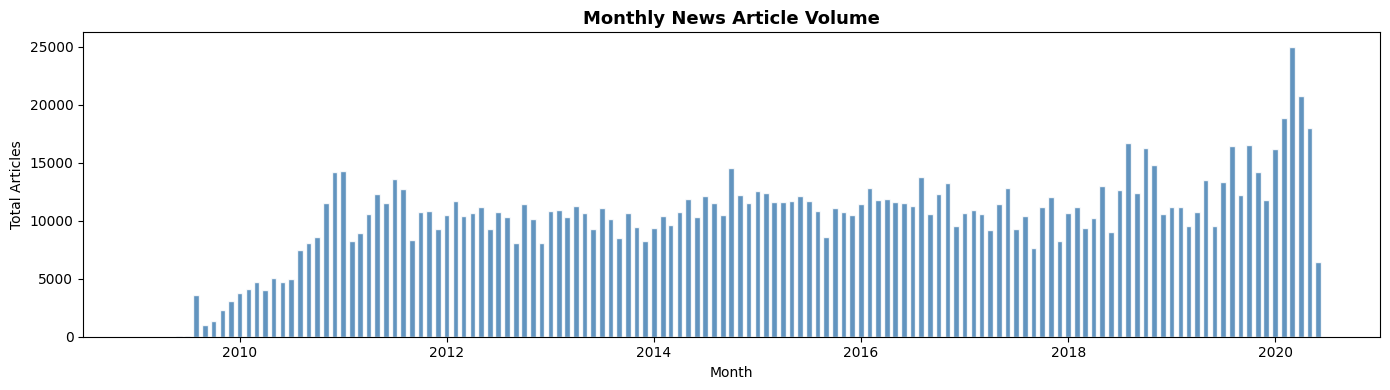

In [89]:
# Resample to monthly frequency — 'MS' = Month Start
monthly_volume = daily_volume.resample('MS').sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_volume.index, monthly_volume.values,
       width=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Monthly News Article Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Articles')
plt.tight_layout()
plt.show()

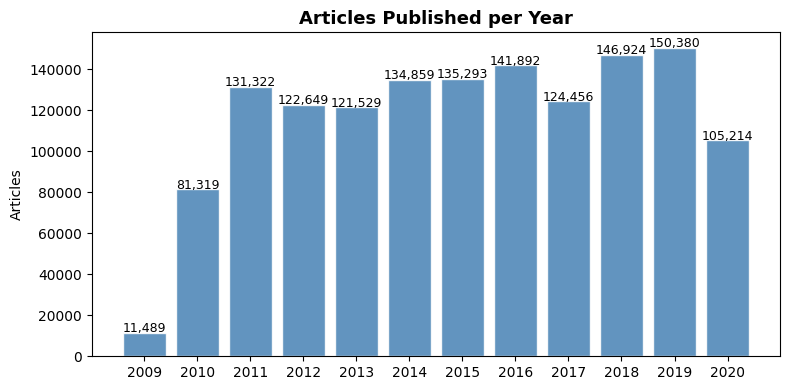

In [90]:
#year over year trend

df['year'] = df['date'].dt.year
yearly = df.groupby('year').size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yearly.index.astype(str), yearly.values,
       color='steelblue', edgecolor='white', alpha=0.85)
for i, (yr, val) in enumerate(yearly.items()):
    ax.text(i, val + 200, f'{val:,}', ha='center', fontsize=9)
ax.set_title('Articles Published per Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Articles')
plt.tight_layout()
plt.show()

## Text Analysis — Keywords & Topic Modeling
Before feeding text to any NLP methods:
- Lowercase everything
- Remove punctuation and numbers
- Remove common English stop words ("the", "a", "is" etc.) that carry no meaning

In [91]:
### processing headline for NLP

# Standard English stop words — sklearn has a built-in list
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Add finance-specific words that are too generic to be useful
extra_stops = {'stock', 'stocks', 'share', 'shares', 'company', 'companies',
               'market', 'markets', 'new', 'week', 'today', 'says', 'said'}
STOP_WORDS = ENGLISH_STOP_WORDS.union(extra_stops)

def clean_headline(text: str) -> str:
    """
    Lowercase, remove punctuation/digits, strip extra whitespace.
    Returns a clean string ready for vectorisation.
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only a-z and spaces
    text = re.sub(r'\s+', ' ', text).strip() # collapse multiple spaces
    return text

df['clean_headline'] = df['headline'].apply(clean_headline)

# Preview
df[['headline', 'clean_headline']].head(3)

,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stocks that hit week highs on friday
1,Stocks That Hit 52-Week Highs On Wednesday,stocks that hit week highs on wednesday
2,71 Biggest Movers From Friday,biggest movers from friday


In [92]:
### most frequent words in headlines.

# CountVectorizer — unigrams only, ignoring stop words, minimum 50 appearances
cv = CountVectorizer(
    stop_words=list(STOP_WORDS),
    min_df=50,          # ignore words appearing in fewer than 50 articles
    ngram_range=(1, 1)  # single words
)

cv_matrix = cv.fit_transform(df['clean_headline'])

# Sum each column → total count for each word
word_counts = pd.Series(
    cv_matrix.sum(axis=0).A1,
    index=cv.get_feature_names_out()
).sort_values(ascending=False)

print('Top 20 most frequent words:')
print(word_counts.head(6).to_frame('Count'))

Top 20 most frequent words:
           Count
vs        162124
est       140650
eps       128917
reports   108710
update     91723
earnings   87399


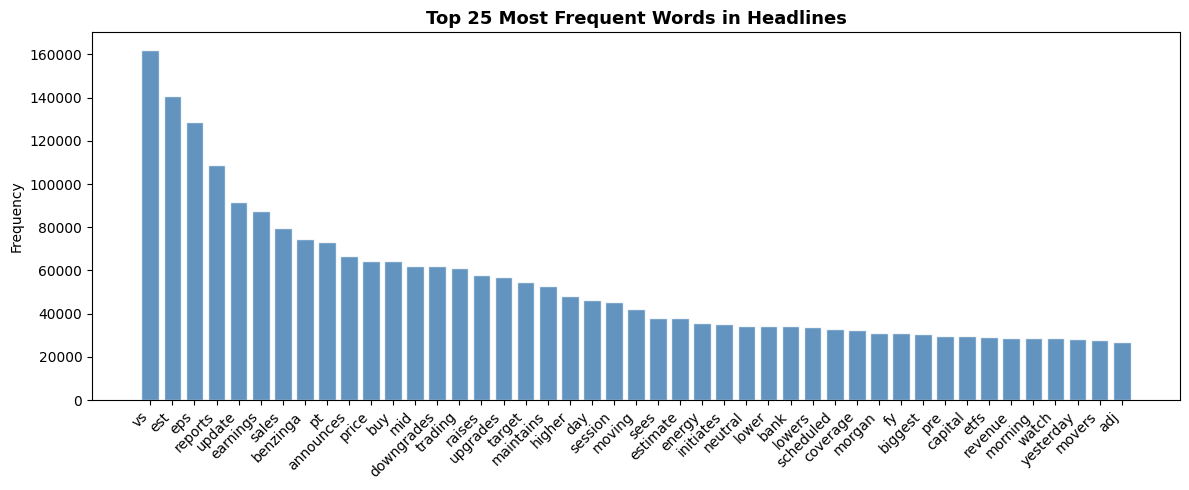

In [93]:
# Bar chart of top 25 words
top25 = word_counts.head(45)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top25.index, top25.values, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Top 25 Most Frequent Words in Headlines', fontsize=13, fontweight='bold')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()